In [ ]:
# Imports and plotting/warnings setup: numpy, pandas, matplotlib, seaborn; enable inline plots and silence warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load dataset into a pandas DataFrame from data/stud.csv
df = pd.read_csv("data/stud.csv")

In [ ]:
# Display first five rows of the DataFrame for quick inspection
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
# Identify null counts per column using a list comprehension and print the output
# creating loop to iterate over and identify if null: [OUTPUT_EXPRESSION for item in iterable if CONDITION]
output = [feature                # take this column
 for feature in df.columns   # loop through all columns
 if df[feature].isna().sum() >= 0]   # condition

print(output)

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']


In [ ]:
# Alternative null counts listing showing (column, count) pairs
# updating
output = [(feature, df[feature].isna().sum())  # take this column
 for feature in df.columns   # loop through all columns
 if df[feature].isna().sum() >= 0]   # condition

print(output)

[('gender', 0), ('race_ethnicity', 0), ('parental_level_of_education', 0), ('lunch', 0), ('test_preparation_course', 0), ('math_score', 0), ('reading_score', 0), ('writing_score', 0)]


In [ ]:
# Simpler approach: show null counts for all columns using built-in method
df.isnull().sum() # simpler approach 

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [ ]:
# Check for duplicated rows in the DataFrame
# check duplicated
df.duplicated().sum()

0

In [ ]:
# Show DataFrame info (non-null counts and dtypes)
# check null and dtype another way
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
# Show number of unique values per column
# checking number of unique values
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [ ]:
# Identify categorical and numerical feature columns by dtype
# define numerical and categorical feature
categories = [feature for feature in df.columns if df[feature].dtype == 'object']
numerical = [feature for feature in df.columns if df[feature].dtype == 'int64']
print(numerical)

['math_score', 'reading_score', 'writing_score']


In [ ]:
# (Commented) create Total_score and average_Score columns; show first rows
# adding columns for total score and average score
# df['Total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
# df['average_Score'] = df['Total_score']/3
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,average_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


121 → left plot
122 → right plot

<Axes: xlabel='average_Score', ylabel='Count'>

<Axes: xlabel='average_Score', ylabel='Count'>

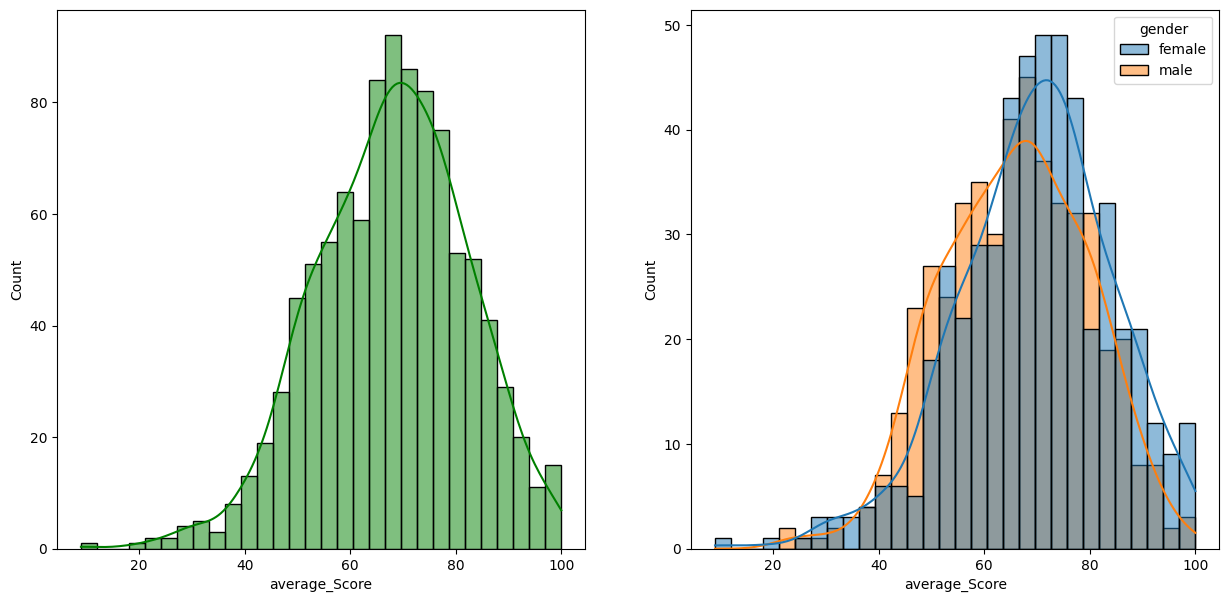

In [ ]:
# Plotting histogram(s) of average_Score; plotting code is commented out
# fig,axs = plt.subplots(1,2, figsize=(15,7))
# plt.subplot(121)
# sns.histplot(data=df, x='average_Score',bins=30,kde=True,color='g')
# plt.subplot(122)
# sns.histplot(data=df, x='average_Score',bins=30,kde=True,hue='gender')

### Modelling

In [ ]:
# ML imports: models, model selection, metrics, and boosting libraries
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Prepare features matrix X and target vector Y; drop direct target proxies where intended
#Preparing X & y
X = df.drop(['math_score'
            #  ,'reading_score','writing_score'
            #  ,'Total_score','average_Score'
             ], axis=1) # remove direct target proxies
Y = df['math_score']
X.info()
# print(type(X))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
dtypes: object(5)
memory usage: 39.2+ KB


### Column transformer, first separate numerical and categorical in X

In [ ]:
# Determine numerical and categorical columns in X

X_numerical = [feature for feature in X.columns if X[feature].dtype != 'O']     # way 1
X_categorical = X.select_dtypes(include='object').columns                       # way 2
X_categorical  
# print(type(X)) 

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object')

In [ ]:
# Build transformers for numerical and categorical features and create ColumnTransformer 'preprocessor'
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer([
        ("numerical", numeric_transformer, X_numerical),
        ("categorical", categorical_transformer, X_categorical)
])
# print(type(X))

In [ ]:
# IMPORTANT: Preprocessor is being fit on the full dataset before splitting — this can cause data leakage. Prefer to split then fit on X_train.
X = preprocessor.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=43, test_size=0.2)
# X_train = preprocessor.fit_transform(X_train)

# X_test = preprocessor.transform(X_test)


In [ ]:
# Display the preprocessed feature matrix (dense/sparse output depends on transformers)
X

<1000x17 sparse matrix of type '<class 'numpy.float64'>'
	with 5000 stored elements in Compressed Sparse Row format>

In [ ]:
# Show shapes of training and testing feature arrays
X_train.shape, X_test.shape

((800, 17), (200, 17))

## Create an evaluate function

In [ ]:
# Define helper function 'evaluate' returning MAE, MSE, RMSE, and R^2 for predictions

def evaluate(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true,predicted)
    return mae,mse,rmse,r2_square


In [ ]:
# Train a set of regression models, predict on train/test sets, and print evaluation metrics

models = {
    "linear regression" : LinearRegression(),
    "lasso": Lasso(),
    "Ridge": Ridge(),
    "knear": KNeighborsRegressor(),
    "svm": SVR(),
    "decision tree": DecisionTreeRegressor(),
    "adaboost": AdaBoostRegressor(),
    "random forest": RandomForestRegressor(),
    "catboosting" : CatBoostRegressor(),
    "xgbboost" : XGBRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    print(list(models.keys())[i])
    # print(list(model.values())[i])
    model = list(models.values())[i]
    # train model
    model.fit(X_train,Y_train)
    #make predictions
    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    #Evaluate model train metrics
    mae_train , mse_train ,rmse_train, r2score_train = evaluate(Y_train, Y_train_pred)
    mae_test , mse_test ,rmse_test, r2score_test = evaluate(Y_test, Y_test_pred)
    
    # print(list(model.keys())[i])
    print("train data result+++++++++++++")
    print(f"mae: {mae_train}, mse {mse_train}, rmse {rmse_train}, r2score {r2score_train}")
    print("test data result+++++++++++++")
    print(f"mae: {mae_test}, mse {mse_test}, rmse {rmse_test}, r2score {r2score_test}")
    print("\n")


linear regression
train data result+++++++++++++
mae: 10.022125915630866, mse 155.95612581140162, rmse 12.488239500081733, r2score 0.2439145023721505
test data result+++++++++++++
mae: 10.031078095983016, mse 147.6636422327126, rmse 12.151692978046828, r2score 0.2108254518610213


lasso
train data result+++++++++++++
mae: 10.722523378542315, mse 182.14676265591294, rmse 13.496175853030108, r2score 0.11694058205484459
test data result+++++++++++++
mae: 10.669282569606041, mse 170.31874600546936, rmse 13.050622437472834, r2score 0.08974736511892001


Ridge
train data result+++++++++++++
mae: 10.021670131731373, mse 155.9576034998301, rmse 12.488298663141833, r2score 0.24390733844200674
test data result+++++++++++++
mae: 10.032399180176967, mse 147.6792012375269, rmse 12.152333160242394, r2score 0.21074229821257973


knear
train data result+++++++++++++
mae: 9.408583333333333, mse 139.03942777777777, rmse 11.791498114225256, r2score 0.32592776080895025
test data result+++++++++++++
mae: 1

In [ ]:
# Diagnostic output: print ranges of actual and predicted test targets and sample pairs; check target dtype
print("Y_test range:", Y_test.min(), "-", Y_test.max())
print("Y_test_pred range:", Y_test_pred.min(), "-", Y_test_pred.max())
print("First 10 actual vs predicted:", list(zip(Y_test.values[:10], Y_test_pred[:10])))
print("\nTarget dtype:", Y.dtype, "Target name:", Y.name)
# print("Total_score in df range:", df['Total_score'].min(), "-", df['Total_score'].max())
# print("Average_score in df range:", df['average_Score'].min(), "-", df['average_Score'].max())

Y_test range: 26.0 - 100.0
Y_test_pred range: 42.75118 - 97.58815
First 10 actual vs predicted: [(49.0, 65.072266), (50.0, 69.122185), (68.0, 76.77194), (59.333333333333336, 58.989082), (89.0, 90.72046), (73.66666666666667, 64.58307), (87.66666666666667, 67.07814), (69.66666666666667, 60.672146), (82.33333333333333, 66.976395), (52.0, 84.01848)]

Target dtype: float64 Target name: average_Score
Total_score in df range: 27 - 300
Average_score in df range: 9.0 - 100.0
